In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Load data
data = pd.read_csv('Spotify Most Streamed Songs.csv', delimiter=',')


In [2]:
# Select numeric features for analysis (skip categorical features)
numerical_features = ['released_year', 'released_month', 'released_day', 'in_spotify_playlists',
                      'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts',
                      'bpm', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%',
                      'instrumentalness_%', 'liveness_%', 'speechiness_%']

# Standardize data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[numerical_features])


In [3]:
# Apply PCA
pca = PCA(n_components=2)  # Reduce to 2 components for visualization
pca_result = pca.fit_transform(scaled_data)


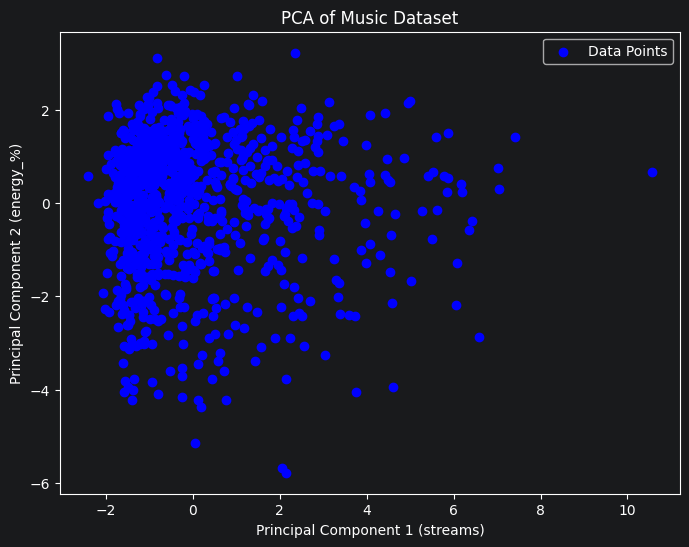

In [4]:
# Visualize the first two principal components
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c='blue', label='Data Points')
plt.title('PCA of Music Dataset')

# Set axes to show the principal components with the largest contribution
component_names = np.array(numerical_features)[np.argmax(abs(pca.components_), axis=1)]

plt.xlabel(f'Principal Component 1 ({component_names[0]})')
plt.ylabel(f'Principal Component 2 ({component_names[1]})')

plt.legend()
plt.show()


In [5]:
# Print explained variance
print("Explained variance ratio: ", pca.explained_variance_ratio_)

# Print principal components
print("Principal Components:\n", pca.components_)

# Map components to original features
print("Corresponding features:\n", numerical_features)


Explained variance ratio:  [0.18913615 0.13046729]
Principal Components:
 [[-0.21814811 -0.05479943 -0.02680323  0.49436819  0.25172333  0.50296522
   0.49615391  0.33595095  0.01624204 -0.0784209   0.01140851  0.03815877
  -0.03989796 -0.02768306 -0.03518921 -0.13161815]
 [ 0.20635747 -0.11106995  0.09228436 -0.05135433  0.15288215 -0.05791989
   0.03073126  0.13303264 -0.008684    0.4350868   0.41519973  0.52877128
  -0.46286443 -0.13927831  0.05385784  0.10319024]]
Corresponding features:
 ['released_year', 'released_month', 'released_day', 'in_spotify_playlists', 'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts', 'bpm', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']
